In [41]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import joblib
import os
import matplotlib.dates as mdates

## Load Data and prep features

In [24]:
df = pd.read_parquet('pm25_tcn.parquet')
df['datetime'] = pd.to_datetime(df['datetime'])


# cyclical time encoding
# hour of day cycle - diurnal patterns
df['hour_sin'] = np.sin(2 * np.pi * df['datetime'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['datetime'].dt.hour / 24)

# day of year cycle - seasonal trends
df['day_sin'] = np.sin(2 * np.pi * df['datetime'].dt.dayofyear / 365)
df['day_cos'] = np.cos(2 * np.pi * df['datetime'].dt.dayofyear / 365)

df = df.sort_values(by=['site_id', 'datetime'])

FEATURE_COLS = [
    'pm_filled', 'wind_speed', 'wind_dir', 
    'hour_sin', 'hour_cos',
    'day_sin', 'day_cos',
    'smoke_prox_1', 'smoke_prox_2', 'smoke_prox_3',
    'fire_prox_1', 'fire_prox_2', 'fire_prox_3'
]

TARGET_COL = 'pm_filled'
SEQ_LEN = 24
HORIZON = 1

In [25]:
df.head()

,datetime,site_id,pm_filled,qc_weight,wind_speed,wind_dir,met_prox,smoke_prox_1,smoke_prox_2,smoke_prox_3,fire_prox_1,fire_prox_2,fire_prox_3,hour_sin,hour_cos,day_sin,day_cos
0,2020-01-01 08:00:00,06-007-0008-3,26.0,1.0,0.1,194.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,8.660254e-01,-0.500000,0.017213,0.999852
1,2020-01-01 09:00:00,06-007-0008-3,31.0,1.0,0.8,166.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,7.071068e-01,-0.707107,0.017213,0.999852
2,2020-01-01 10:00:00,06-007-0008-3,29.0,1.0,2.0,204.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000e-01,-0.866025,0.017213,0.999852
3,2020-01-01 11:00:00,06-007-0008-3,21.0,1.0,0.5,288.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,2.588190e-01,-0.965926,0.017213,0.999852
4,2020-01-01 12:00:00,06-007-0008-3,18.0,1.0,2.2,349.0,10000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.224647e-16,-1.000000,0.017213,0.999852


In [26]:
# Filter features
available_features = [c for c in FEATURE_COLS if c in df.columns]
target_idx = available_features.index(TARGET_COL)

# Split Train/Test
split_date = df['datetime'].quantile(0.8)
train_df = df[df['datetime'] < split_date].copy()
test_df = df[df['datetime'] >= split_date].copy()

# Scale
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[available_features])
test_scaled = scaler.transform(test_df[available_features])

In [27]:
class AirQualityDataset(Dataset):
    def __init__(self, data, seq_len, horizon, target_idx):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.horizon = horizon
        self.target_idx = target_idx
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1
    
    def __getitem__(self, idx):
        # Input: (Seq_Len, Features) -> PyTorch expects (Features, Seq_Len) for Conv1d
        x = self.data[idx : idx + self.seq_len]
        x = x.transpose(0, 1) # Swap to (C, L) format
        
        # Output: Scalar value
        y = self.data[idx + self.seq_len + self.horizon - 1, self.target_idx]
        return x, y

# Create Loaders
train_dataset = AirQualityDataset(train_scaled, SEQ_LEN, HORIZON, target_idx)
test_dataset = AirQualityDataset(test_scaled, SEQ_LEN, HORIZON, target_idx)

# Batch size 64 is good for TCN
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## TCN Architecture

In [29]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super(CausalConv1d, self).__init__()
        # Padding calculation: (K-1) * D
        self.padding = (kernel_size - 1) * dilation
        
        self.conv = nn.Conv1d(
            in_channels, 
            out_channels, 
            kernel_size, 
            padding=self.padding, 
            dilation=dilation
        )
        
    def forward(self, x):
        x = self.conv(x)
        # Remove the padding from the right (future) side to maintain causality
        return x[:, :, :-self.padding]

class TCNModel(nn.Module):
    def __init__(self, num_inputs, num_channels=64, kernel_size=3, dropout=0.2):
        super(TCNModel, self).__init__()
        
        # Layer 1: Dilation 1 (Look at immediate past)
        self.tcn1 = CausalConv1d(num_inputs, num_channels, kernel_size, dilation=1)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)
        
        # Layer 2: Dilation 2 (Look 2 steps back)
        self.tcn2 = CausalConv1d(num_channels, num_channels, kernel_size, dilation=2)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)
        
        # Layer 3: Dilation 4 (Look 4 steps back)
        self.tcn3 = CausalConv1d(num_channels, num_channels, kernel_size, dilation=4)
        self.relu3 = nn.ReLU()
        self.drop3 = nn.Dropout(dropout)
        
        # # Output Layer: Linear map to 1 predicted value
        # self.linear = nn.Linear(num_channels, 1)
        self.linear = nn.Linear(num_channels, 2)
        
    def forward(self, x):
        # x shape: (Batch, Features, Seq_Len)
        
        y1 = self.drop1(self.relu1(self.tcn1(x)))
        y2 = self.drop2(self.relu2(self.tcn2(y1)))
        y3 = self.drop3(self.relu3(self.tcn3(y2)))
        
        # Take the LAST time step only (Predict based on full history)
        # shape becomes (Batch, Channels)
        last_step = y3[:, :, -1] 
        
        output = self.linear(last_step)
        
        mu = output[:, 0]
        log_var = output[:, 1]
        
        return mu, log_var

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TCNModel(num_inputs=len(available_features)).to(device)
# print(model)

In [30]:
def gaussian_nll_loss(mu, log_var, target):
    # Calculate Variance from Log Variance
    var = torch.exp(log_var)
    
    # Gaussian NLL Formula: 0.5 * (log(var) + (target - mu)^2 / var)
    # We add a constant for stability usually, but this is the core math
    loss = 0.5 * (log_var + (target - mu)**2 / var)
    
    return loss.mean()

## Training

In [32]:
criterion = gaussian_nll_loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 5
train_losses = []
test_losses = []

print("Starting Training...\n")

for epoch in range(num_epochs):
    
    # 1. TRAINING
    model.train()
    running_loss = 0.0
    
    # 'leave=False' means the bar disappears after the epoch finishes, 
    # leaving only your clean print statement behind. 
    # Change to True if you want to keep the bars.
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    loop.set_description(f"Epoch {epoch+1}/{num_epochs}")
    
    for X_batch, y_batch in loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        mu, log_var = model(X_batch)
        loss = criterion(mu, log_var, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Live update of the batch loss in the progress bar
        loop.set_postfix(loss=loss.item())
    
    # 2. VALIDATION
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            mu, log_var = model(X_val)
            loss = criterion(mu, log_var, y_val)
            val_loss += loss.item()
            
    # 3. CALCULATE AVERAGES
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    
    train_losses.append(avg_train_loss)
    test_losses.append(avg_val_loss)
    
    # 4. EXPLICIT PRINT (The Clean Log)
    # This prints the permanent record for the epoch
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

print("\nTraining Complete.")

Starting Training...



Epoch 1/5: 100%|██████████| 7277/7277 [02:02<00:00, 59.54it/s, loss=-4.08]  


Epoch 1/5 | Train Loss: -4.28828 | Val Loss: -4.43561


Epoch 2/5: 100%|██████████| 7277/7277 [02:02<00:00, 59.46it/s, loss=-4.65] 


Epoch 2/5 | Train Loss: -4.33817 | Val Loss: -4.70092


...

Epoch 3/5 | Train Loss: -4.47276 | Val Loss: -4.78961


Epoch 4/5: 100%|██████████| 7277/7277 [02:01<00:00, 60.10it/s, loss=-5.01]  


Epoch 4/5 | Train Loss: -4.49931 | Val Loss: -4.79837


Epoch 5/5: 100%|██████████| 7277/7277 [02:02<00:00, 59.19it/s, loss=-4.78] 


Epoch 5/5 | Train Loss: -4.53874 | Val Loss: -4.56569

Training Complete.


In [35]:
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

# 1. Save the Model State Dictionary (Weights & Biases)
# This is the recommended way (lighter and more stable than saving the whole object)
torch.save(model.state_dict(), 'saved_models/tcn_wildfire_model.pth')
print("Model weights saved to 'saved_models/tcn_wildfire_model.pth'")

# 2. Save the Scaler
# You MUST save this. If you lose the scaler, your model's predictions 
# (which are 0.0 to 1.0) cannot be converted back to µg/m³.
joblib.dump(scaler, 'saved_models/scaler.pkl')
print("Scaler saved to 'saved_models/scaler.pkl'")

Model weights saved to 'saved_models/tcn_wildfire_model.pth'
Scaler saved to 'saved_models/scaler.pkl'


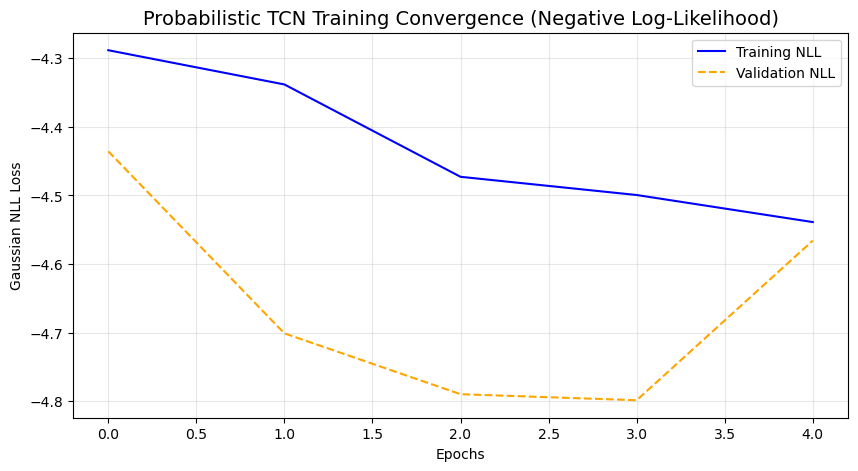

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training NLL', color='blue', linestyle='-')
plt.plot(test_losses, label='Validation NLL', color='orange', linestyle='--')

plt.title('Probabilistic TCN Training Convergence (Negative Log-Likelihood)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Gaussian NLL Loss')
plt.legend()
plt.grid(True, alpha=0.3)


plt.show()

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Setup Feature Columns (Matching your Cell 19)
FEATURE_COLS = [
    'pm_filled', 'wind_speed', 'wind_dir', 
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'smoke_prox_1', 'smoke_prox_2', 'smoke_prox_3',
    'fire_prox_1', 'fire_prox_2', 'fire_prox_3'
]

# 2. Re-Load Full Data (to ensure we cover all sites)
df_full = pd.read_parquet('pm25_tcn.parquet')
df_full['datetime'] = pd.to_datetime(df_full['datetime'])

# Re-create cyclic features (Safety step)
df_full['hour_sin'] = np.sin(2 * np.pi * df_full['datetime'].dt.hour / 24)
df_full['hour_cos'] = np.cos(2 * np.pi * df_full['datetime'].dt.hour / 24)
df_full['day_sin'] = np.sin(2 * np.pi * df_full['datetime'].dt.dayofyear / 365)
df_full['day_cos'] = np.cos(2 * np.pi * df_full['datetime'].dt.dayofyear / 365)

sites = df_full['site_id'].unique()
site_rmses = []
site_maes = []

print(f"Calculating Average RMSE across {len(sites)} sites...")

model.eval()
with torch.no_grad():
    for site_id in sites:
        # Filter data for this site
        df_site = df_full[df_full['site_id'] == site_id].sort_values('datetime').reset_index(drop=True)
        
        # Transform Features
        site_data_scaled = scaler.transform(df_site[FEATURE_COLS])
        
        # Create Loader (Batch size 512 for speed)
        ds = AirQualityDataset(site_data_scaled, seq_len=24, horizon=1, target_idx=0)
        loader = DataLoader(ds, batch_size=512, shuffle=False)
        
        preds = []
        actuals = []
        
        # Inference
        for X, y in loader:
            X = X.to(device)
            mu, _ = model(X) # We only need the Mean for RMSE
            preds.extend(mu.cpu().numpy())
            actuals.extend(y.numpy())
            
        # Inverse Transform
        y_pred = inverse_transform_target(np.array(preds), scaler, 0, len(FEATURE_COLS))
        y_true = inverse_transform_target(np.array(actuals), scaler, 0, len(FEATURE_COLS))
        
        # Calculate Metric for this site
        site_rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
        site_maes.append(mean_absolute_error(y_true, y_pred))

# 3. Print the Macro-Average (The number to give your teammate)
print("="*40)
print(f"Average RMSE (Across all sites): {np.mean(site_rmses):.2f} µg/m³")
print(f"Average MAE  (Across all sites): {np.mean(site_maes):.2f} µg/m³")
print("="*40)

Calculating Average RMSE across 15 sites...
Average RMSE (Across all sites): 7.30 µg/m³
Average MAE  (Across all sites): 4.51 µg/m³


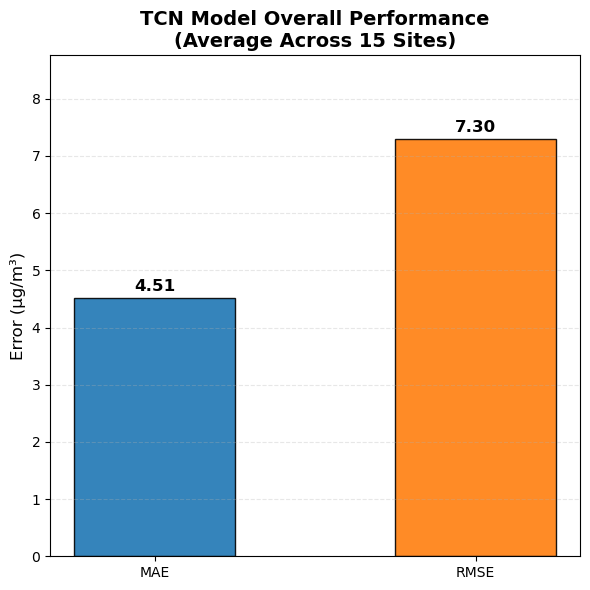

In [52]:
# --- 1. YOUR DATA ---
metrics = ['MAE', 'RMSE']
values = [4.51, 7.30]  # The exact numbers you provided
colors = ['#1f77b4', '#ff7f0e'] # Blue for RMSE, Orange for MAE

# --- 2. CREATE PLOT ---
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Bars
bars = ax.bar(metrics, values, color=colors, alpha=0.9, edgecolor='black', width=0.5)

# Formatting
ax.set_ylabel('Error (µg/m³)', fontsize=12)
ax.set_title('TCN Model Overall Performance\n(Average Across 15 Sites)', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Set y-limit to give some headroom
ax.set_ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

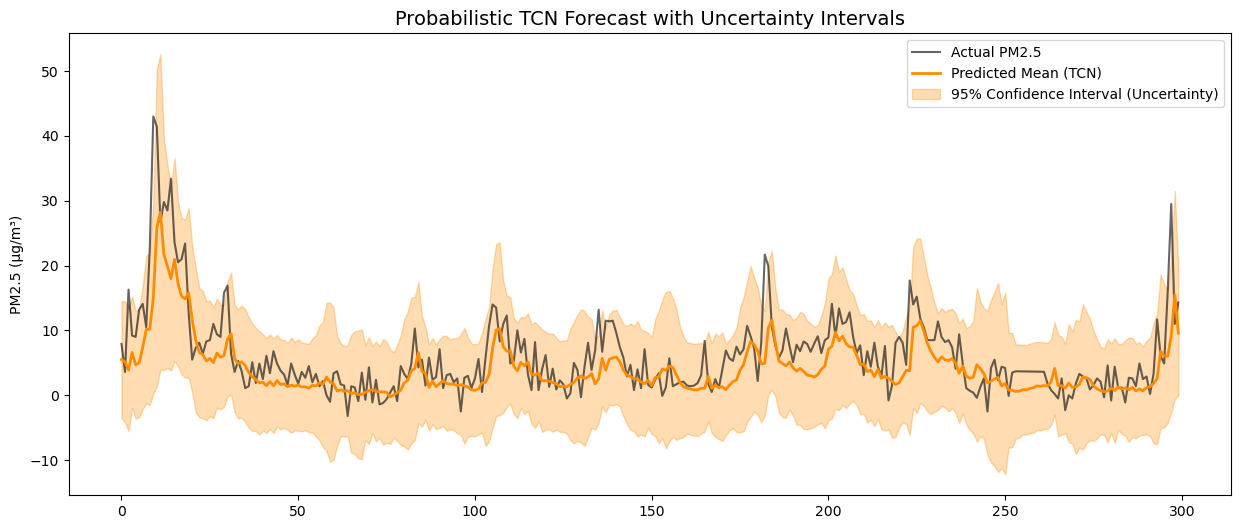

In [33]:
model.eval()
all_preds_mu = []
all_preds_sigma = []
all_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        
        # Get Mean and Log-Variance
        mu, log_var = model(X_batch)
        
        # Convert Log-Variance to Standard Deviation (Sigma)
        sigma = torch.exp(0.5 * log_var)
        
        all_preds_mu.extend(mu.cpu().numpy())
        all_preds_sigma.extend(sigma.cpu().numpy())
        all_actuals.extend(y_batch.numpy())

# Convert to arrays
y_pred_mu = np.array(all_preds_mu)
y_pred_sigma = np.array(all_preds_sigma)
y_true = np.array(all_actuals)

# --- INVERSE TRANSFORM (Back to Real Units) ---
# Note: We must scale Sigma as well! 
# If data was scaled by (max - min), sigma must be multiplied by (max - min)
scale_factor = scaler.data_range_[target_idx] # Range of the target column
y_pred_real = inverse_transform_target(y_pred_mu, scaler, target_idx, len(available_features))
y_true_real = inverse_transform_target(y_true, scaler, target_idx, len(available_features))
y_sigma_real = y_pred_sigma * scale_factor

# --- PLOTTING WITH UNCERTAINTY ---
start_idx = -300
plt.figure(figsize=(15, 6))

# 1. Plot Actual
plt.plot(y_true_real[start_idx:], label='Actual PM2.5', color='black', alpha=0.6)

# 2. Plot Predicted Mean
plt.plot(y_pred_real[start_idx:], label='Predicted Mean (TCN)', color='#FF8C00', linewidth=2)

# 3. Plot Uncertainty (95% Confidence Interval = +/- 2 Sigma)
lower_bound = y_pred_real[start_idx:] - 2 * y_sigma_real[start_idx:]
upper_bound = y_pred_real[start_idx:] + 2 * y_sigma_real[start_idx:]

plt.fill_between(
    range(len(lower_bound)), 
    lower_bound, 
    upper_bound, 
    color='#FF8C00', 
    alpha=0.3, 
    label='95% Confidence Interval (Uncertainty)'
)

plt.title('Probabilistic TCN Forecast with Uncertainty Intervals', fontsize=14)
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.show()

Standard MAE (All Data):  2.60 µg/m³
Smoke MAE (PM2.5 > 35): 16.34 µg/m³


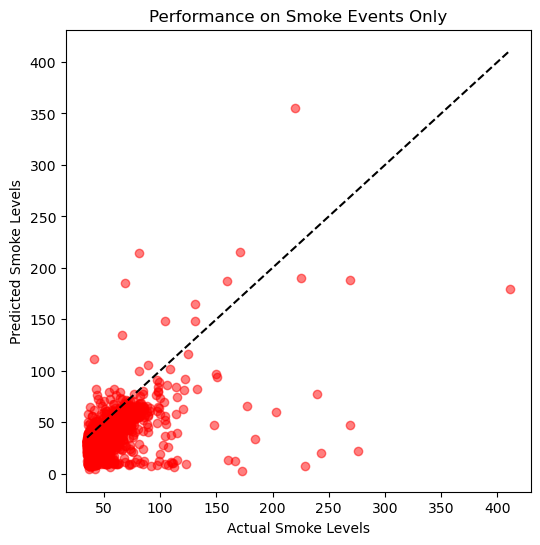

In [22]:
import numpy as np

# Define a threshold for "Smoke/Unhealthy" (EPA standard is 35)
smoke_threshold = 35

# Filter for rows where the ACTUAL value was high
mask = y_true_real >= smoke_threshold
high_pm_actual = y_true_real[mask]
high_pm_pred = y_pred_real[mask]

if len(high_pm_actual) > 0:
    smoke_mae = np.mean(np.abs(high_pm_actual - high_pm_pred))
    print(f"Standard MAE (All Data):  2.60 µg/m³")
    print(f"Smoke MAE (PM2.5 > {smoke_threshold}): {smoke_mae:.2f} µg/m³")
    
    # Optional: Scatter plot for high values
    plt.figure(figsize=(6, 6))
    plt.scatter(high_pm_actual, high_pm_pred, alpha=0.5, color='red')
    plt.plot([smoke_threshold, max(high_pm_actual)], [smoke_threshold, max(high_pm_actual)], 'k--') # Perfect prediction line
    plt.xlabel('Actual Smoke Levels')
    plt.ylabel('Predicted Smoke Levels')
    plt.title('Performance on Smoke Events Only')
    plt.show()
else:
    print("No smoke events (> 35) found in this test batch.")

## Site specific timeline

In [55]:
# 1. Configuration
SITE_ID = '06-019-0011-3'  # Example: Fresno (Central Valley, fire prone)
# SITE_ID = '06-001-0013-3' # Alternative: Alameda
SEQ_LEN = 24  # Must match what you trained with
BATCH_SIZE = 64

# 2. Load and Filter Data
# We go back to the source to get the full 2020-2024 range
df_full = pd.read_parquet('pm25_tcn.parquet')
df_site = df_full[df_full['site_id'] == SITE_ID].copy()
df_site = df_site.sort_values('datetime').reset_index(drop=True)

# 3. Re-Create Features (Must match training exactly)
df_site['datetime'] = pd.to_datetime(df_site['datetime'])
df_site['hour_sin'] = np.sin(2 * np.pi * df_site['datetime'].dt.hour / 24)
df_site['hour_cos'] = np.cos(2 * np.pi * df_site['datetime'].dt.hour / 24)
df_site['day_sin'] = np.sin(2 * np.pi * df_site['datetime'].dt.dayofyear / 365)
df_site['day_cos'] = np.cos(2 * np.pi * df_site['datetime'].dt.dayofyear / 365)

# Ensure feature list matches EXACTLY
FEATURE_COLS = [
    'pm_filled', 'wind_speed', 'wind_dir', 
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'smoke_prox_1', 'smoke_prox_2', 'smoke_prox_3',
    'fire_prox_1', 'fire_prox_2', 'fire_prox_3'
]

# 4. Scale the Data
# CRITICAL: Use the SAME scaler you fitted on the training set. Do not refit!
# We transform the features to match the model's expected input range (0-1)
site_data_scaled = scaler.transform(df_site[FEATURE_COLS])

# 5. Create Dataset for this specific site
# We use the AirQualityDataset class you defined earlier
site_dataset = AirQualityDataset(site_data_scaled, SEQ_LEN, HORIZON, target_idx=0)
site_loader = DataLoader(site_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data prepared for Site {SITE_ID}. Total hours: {len(site_dataset)}")

Data prepared for Site 06-019-0011-3. Total hours: 42933


In [56]:
model.eval()
site_preds_mu = []
site_preds_sigma = []
site_actuals = []
site_smoke = []
site_fire = []

# Indices for extraction
SMOKE_IDX = 7
FIRE_IDX = 10 

print("Running inference on full history...")

with torch.no_grad():
    for X_batch, y_batch in site_loader:
        X_batch = X_batch.to(device)
        
        # Predict
        mu, log_var = model(X_batch)
        sigma = torch.exp(0.5 * log_var)
        
        # Extract Features for plotting
        smoke = X_batch[:, SMOKE_IDX, -1].cpu().numpy()
        fire = X_batch[:, FIRE_IDX, -1].cpu().numpy()
        
        # Store
        site_preds_mu.extend(mu.cpu().numpy())
        site_preds_sigma.extend(sigma.cpu().numpy())
        site_actuals.extend(y_batch.numpy())
        site_smoke.extend(smoke)
        site_fire.extend(fire)

# Inverse Transform
n_features = len(FEATURE_COLS)
# Note: We use the helper function 'inverse_transform_target' from previous steps
y_site_real = inverse_transform_target(np.array(site_preds_mu), scaler, 0, n_features)
y_actual_real = inverse_transform_target(np.array(site_actuals), scaler, 0, n_features)

# Scale Sigma
scale_factor = scaler.data_range_[0]
y_sigma_real = np.array(site_preds_sigma) * scale_factor

# Get Dates for the X-axis (Accounting for SEQ_LEN offset)
# The dataset consumes the first SEQ_LEN rows, so predictions start at index SEQ_LEN + HORIZON
dates = df_site['datetime'].iloc[SEQ_LEN + HORIZON - 1:].reset_index(drop=True)

Running inference on full history...


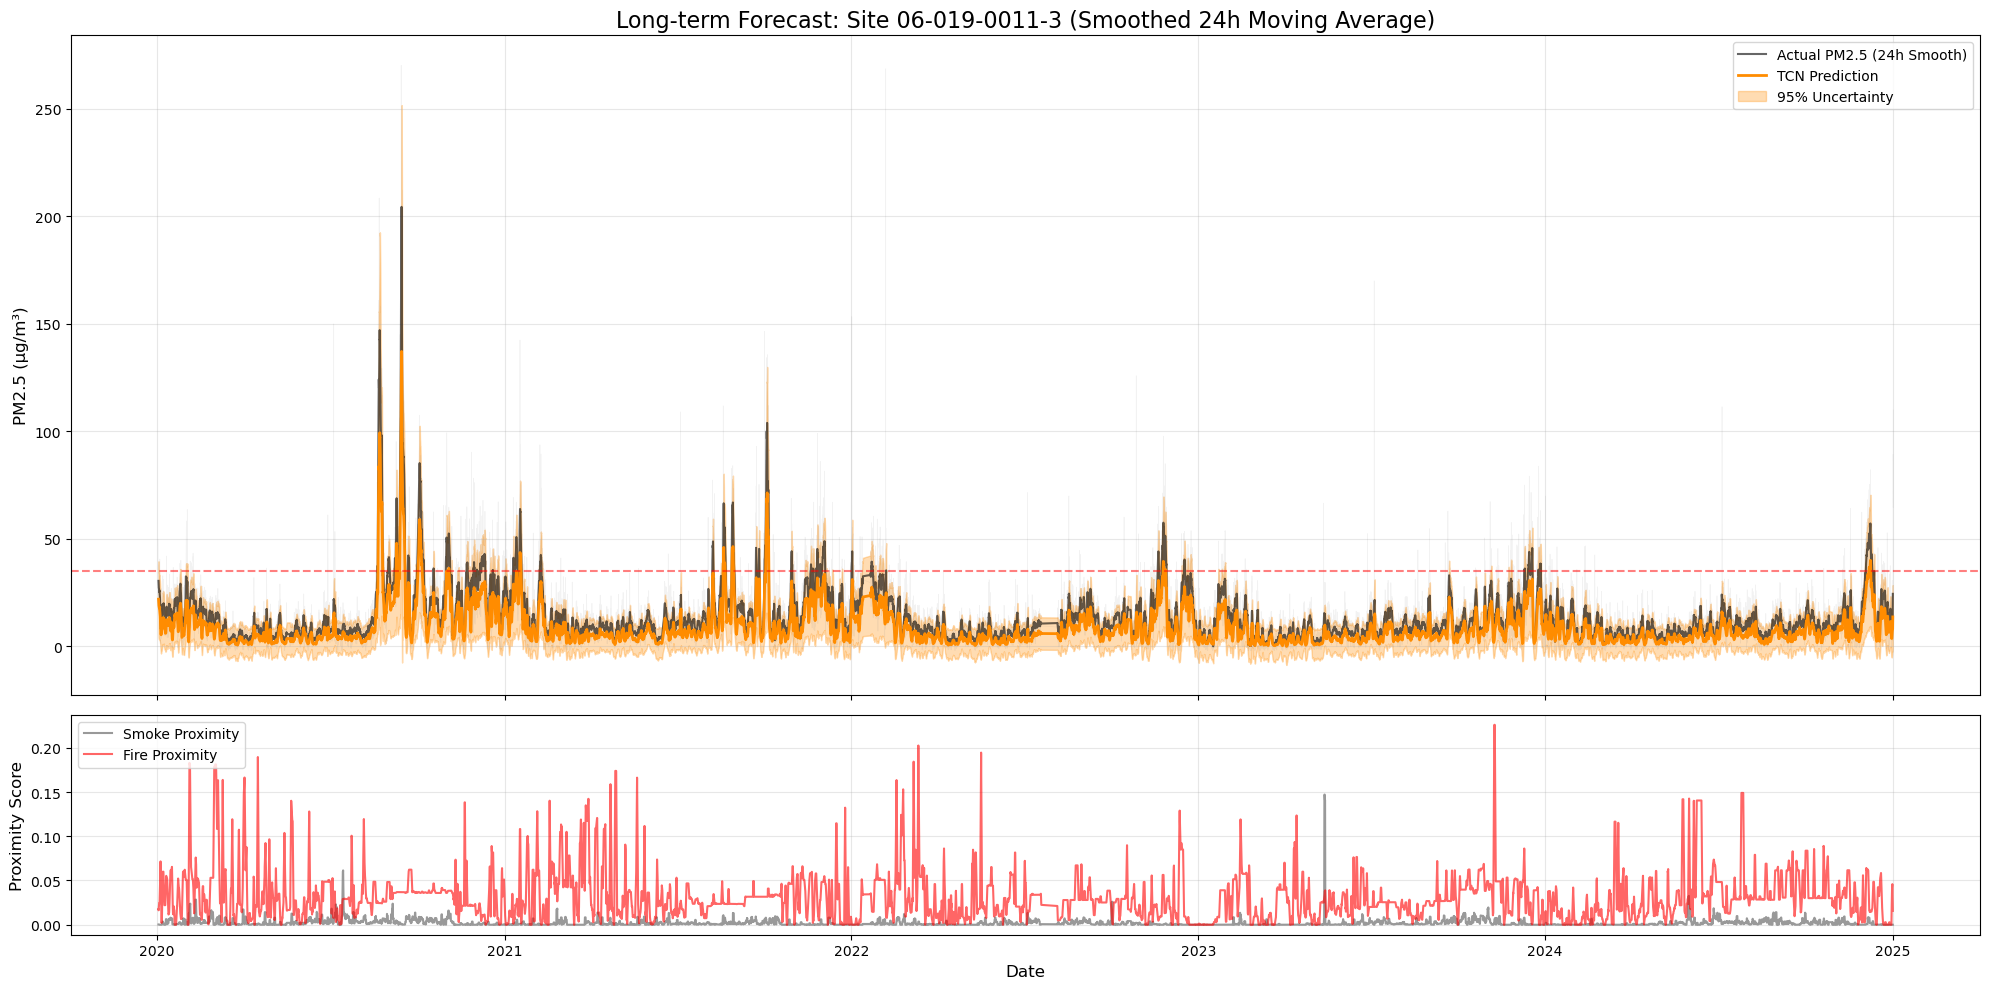

In [57]:
df_plot = pd.DataFrame({
    'date': dates,
    'Actual': y_actual_real,
    'Predicted': y_site_real,
    'Lower': y_site_real - 1.96 * y_sigma_real,
    'Upper': y_site_real + 1.96 * y_sigma_real,
    'Smoke': site_smoke,
    'Fire': site_fire
}).set_index('date')

# 2. Apply Smoothing (Rolling Mean)
# Window = 168 hours (7 Days) to see weekly trends
# Window = 24 hours (1 Day) to see daily trends but keep some spikes
WINDOW = 24  
df_smooth = df_plot.rolling(window=WINDOW, center=True).mean()

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- Top Plot: PM2.5 (Smoothed) ---
# Plot raw actuals faintly in background (optional, shows the noise)
ax1.plot(df_plot.index, df_plot['Actual'], color='gray', alpha=0.1, linewidth=0.5)

# Plot Smoothed Lines
ax1.plot(df_smooth.index, df_smooth['Actual'], color='black', alpha=0.6, linewidth=1.5, label=f'Actual PM2.5 ({WINDOW}h Smooth)')
ax1.plot(df_smooth.index, df_smooth['Predicted'], color='#FF8C00', linewidth=2, label='TCN Prediction')

# Uncertainty Band (Smoothed)
ax1.fill_between(
    df_smooth.index, 
    df_smooth['Lower'], 
    df_smooth['Upper'], 
    color='#FF8C00', alpha=0.3, label='95% Uncertainty'
)

ax1.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax1.set_title(f'Long-term Forecast: Site {SITE_ID} (Smoothed {WINDOW}h Moving Average)', fontsize=16)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Highlight Unhealthy Threshold
ax1.axhline(y=35, color='red', linestyle='--', alpha=0.5, label='Unhealthy Standard')

# --- Bottom Plot: Smoke & Fire (Smoothed) ---
# Smoothing helps show "periods of smoke" rather than instant blips
ax2.plot(df_smooth.index, df_smooth['Smoke'], color='gray', alpha=0.8, label='Smoke Proximity')
ax2.plot(df_smooth.index, df_smooth['Fire'], color='red', alpha=0.6, label='Fire Proximity')

ax2.set_ylabel('Proximity Score', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Format Date Axis
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [59]:
# Calculate Average MAE/RMSE AND Calibration Metrics Together

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def inverse_transform_target(values, scaler, target_idx, n_features):
    """Helper to inverse transform only the target column"""
    dummy = np.zeros((len(values), n_features))
    dummy[:, target_idx] = values
    inverse = scaler.inverse_transform(dummy)
    return inverse[:, target_idx]

# Use the test loader you already created
model.eval()
all_preds_mu = []
all_preds_sigma = []
all_actuals = []

print("Generating predictions on test set...")

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        
        # Get Mean and Log-Variance
        mu, log_var = model(X_batch)
        
        # Convert Log-Variance to Standard Deviation (Sigma)
        sigma = torch.exp(0.5 * log_var)
        
        all_preds_mu.extend(mu.cpu().numpy())
        all_preds_sigma.extend(sigma.cpu().numpy())
        all_actuals.extend(y_batch.numpy())

# Convert to arrays
y_pred_mu = np.array(all_preds_mu)
y_pred_sigma = np.array(all_preds_sigma)
y_true = np.array(all_actuals)

# Inverse Transform (Back to Real Units)
scale_factor = scaler.data_range_[target_idx]
y_pred_real = inverse_transform_target(y_pred_mu, scaler, target_idx, len(available_features))
y_true_real = inverse_transform_target(y_true, scaler, target_idx, len(available_features))
y_sigma_real = y_pred_sigma * scale_factor

# === CALCULATE METRICS ===

# 1. Point Metrics (MAE/RMSE)
mae = mean_absolute_error(y_true_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))

# 2. Calibration Metrics (Uncertainty Quality)
lower_bound_95 = y_pred_real - 1.96 * y_sigma_real
upper_bound_95 = y_pred_real + 1.96 * y_sigma_real

# Check Coverage (PICP)
hits = (y_true_real >= lower_bound_95) & (y_true_real <= upper_bound_95)
picp = np.mean(hits) * 100

# Check Sharpness
avg_width = np.mean(upper_bound_95 - lower_bound_95)

# === DISPLAY RESULTS ===
print("\n" + "="*60)
print("TCN MODEL PERFORMANCE (TEST SET)")
print("="*60)

print("\n--- Point Prediction Accuracy ---")
print(f"MAE:  {mae:.2f} µg/m³")
print(f"RMSE: {rmse:.2f} µg/m³")

print("\n--- Uncertainty Calibration ---")
print(f"Actual Coverage (PICP):     {picp:.2f}%")
print(f"Target Coverage:            95.00%")
print(f"Average Interval Width:     {avg_width:.2f} µg/m³")

# Interpretation
diff = picp - 95
print("\n--- Calibration Assessment ---")
if abs(diff) < 5:
    print("✓ Model is WELL-CALIBRATED")
    print("  Uncertainty intervals are reliable")
elif diff < -5:
    print("⚠ Model is OVER-CONFIDENT")
    print("  Intervals are too narrow - increase dropout")
else:
    print("⚠ Model is UNDER-CONFIDENT")
    print("  Intervals are too wide - train longer or reduce capacity")

print("\n" + "="*60)
print(f"Test Set Size: {len(y_true_real):,} predictions")
print("="*60)

Generating predictions on test set...

TCN MODEL PERFORMANCE (TEST SET)

--- Point Prediction Accuracy ---
MAE:  3.99 µg/m³
RMSE: 6.09 µg/m³

--- Uncertainty Calibration ---
Actual Coverage (PICP):     91.81%
Target Coverage:            95.00%
Average Interval Width:     16.85 µg/m³

--- Calibration Assessment ---
✓ Model is WELL-CALIBRATED
  Uncertainty intervals are reliable

Test Set Size: 116,409 predictions


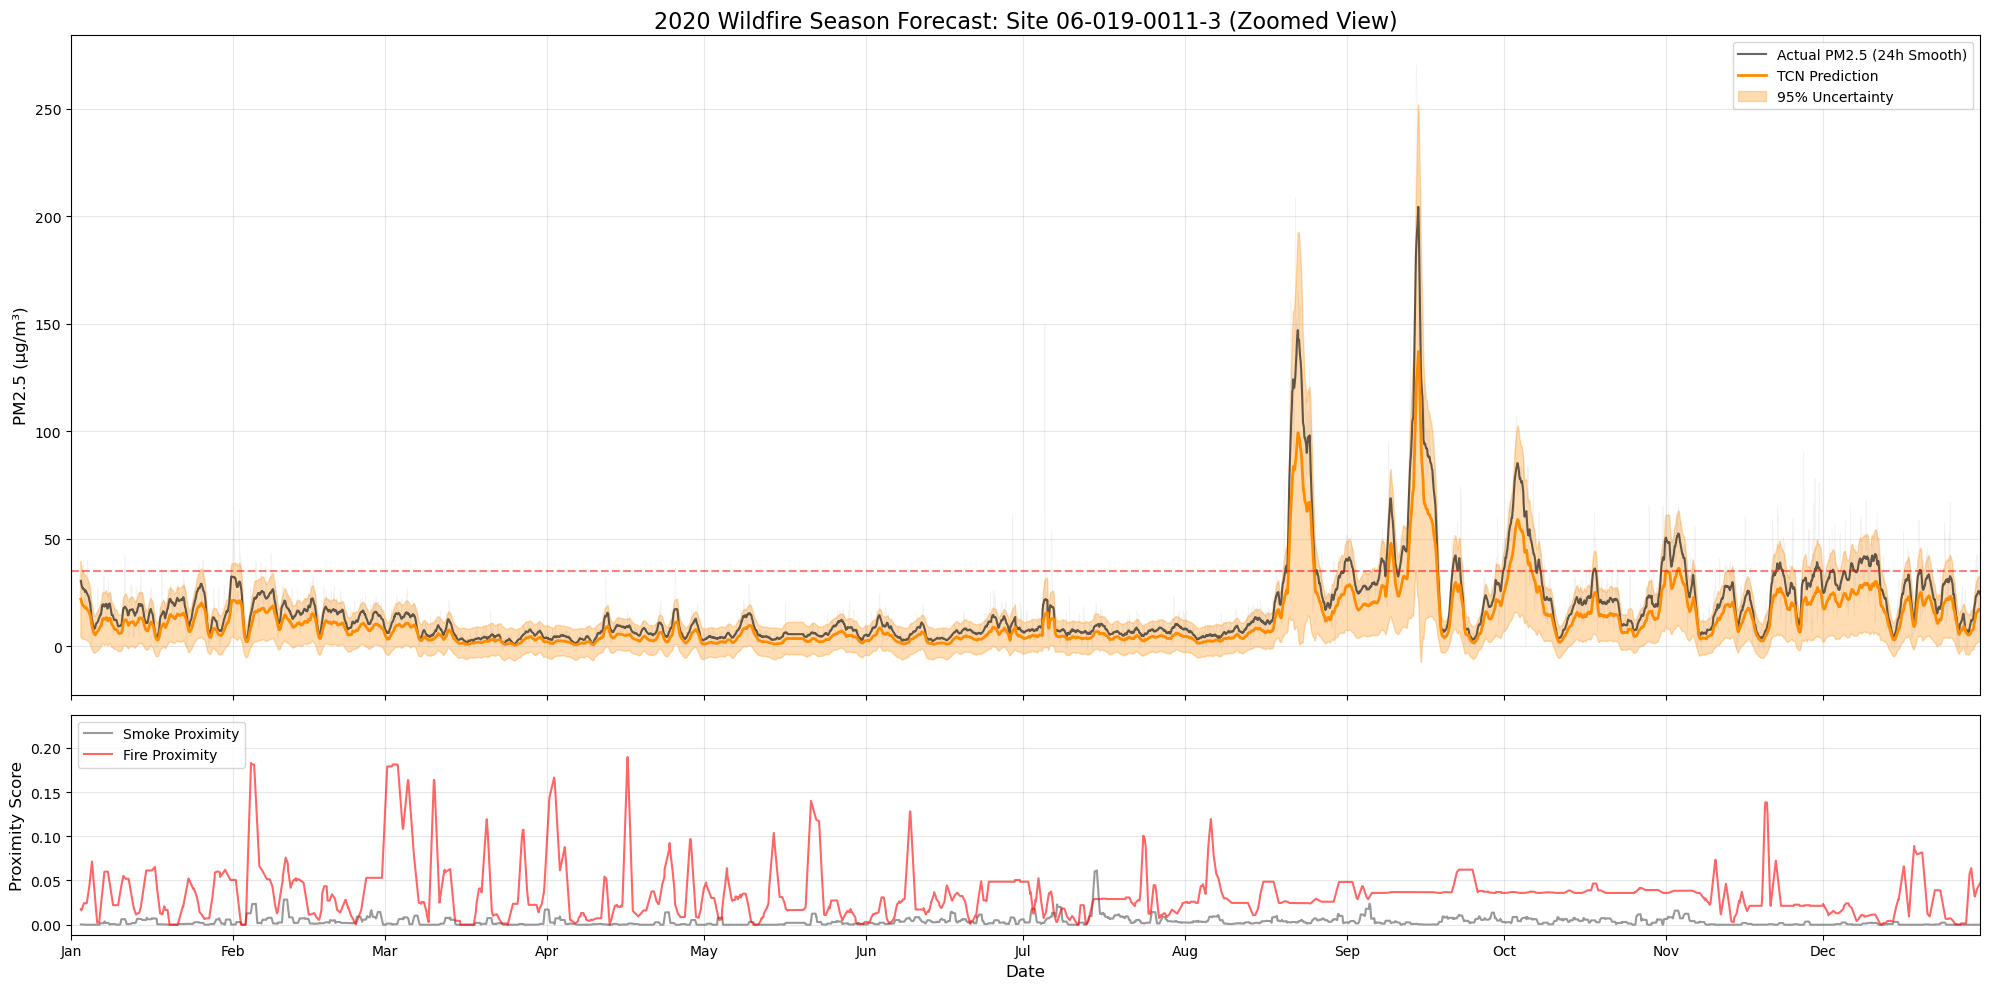

In [46]:
# 3. Plotting (Zoomed into 2020)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- Top Plot: PM2.5 (Smoothed) ---
# Background raw data (optional, restricting to 2020 view automatically via set_xlim later)
ax1.plot(df_plot.index, df_plot['Actual'], color='gray', alpha=0.1, linewidth=0.5)

# Main Smoothed Lines
ax1.plot(df_smooth.index, df_smooth['Actual'], color='black', alpha=0.6, linewidth=1.5, label=f'Actual PM2.5 ({WINDOW}h Smooth)')
ax1.plot(df_smooth.index, df_smooth['Predicted'], color='#FF8C00', linewidth=2, label='TCN Prediction')

# Uncertainty Band
ax1.fill_between(
    df_smooth.index, 
    df_smooth['Lower'], 
    df_smooth['Upper'], 
    color='#FF8C00', alpha=0.3, label='95% Uncertainty'
)

ax1.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax1.set_title(f'2020 Wildfire Season Forecast: Site {SITE_ID} (Zoomed View)', fontsize=16)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Highlight Unhealthy Threshold
ax1.axhline(y=35, color='red', linestyle='--', alpha=0.5, label='Unhealthy Standard')

# --- Bottom Plot: Smoke & Fire ---
ax2.plot(df_smooth.index, df_smooth['Smoke'], color='gray', alpha=0.8, label='Smoke Proximity')
ax2.plot(df_smooth.index, df_smooth['Fire'], color='red', alpha=0.6, label='Fire Proximity')

ax2.set_ylabel('Proximity Score', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# --- CRITICAL STEP: ZOOM IN ---
# This limits the x-axis to the year 2020
ax1.set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'))

# Format Date Axis to show months since we are looking at one year
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()